In [203]:
import sqlite3

import pandas as pd
def run_sql_query(query: str)-> pd.DataFrame:
    conn = sqlite3.connect('../cem_results.db')
    try:
    
        # Execute and load into DataFrame
        df = pd.read_sql_query(query, conn)

    finally:
        conn.close()
    return df

In [204]:

def query_metrics(job_id):
    query = f"""SELECT 
        r.dataset,
        m.entity,
        m.metric_type,
        AVG(m.f1_score) AS mean_f1,
        SQRT((SUM(m.f1_score * m.f1_score) - (SUM(m.f1_score) * SUM(m.f1_score) / COUNT(m.f1_score))) / (COUNT(m.f1_score) - 1)) AS std_f1,
        COUNT(r.seed) AS num_seeds,
        r.train_size,
        r.pollution,
        r.batch_size,
        r.max_len,
        r.learning_rate,
        r.epochs,
        r.lm,
        r.neg_ratio
    FROM runs r
    JOIN metrics m ON r.run_id = m.run_id
    WHERE m.is_final = 1  AND m.run_id LIKE '{job_id}_%'
    GROUP BY 
        r.dataset, 
        r.train_size, 
        r.pollution, 
        r.batch_size, 
        r.max_len, 
        r.learning_rate, 
        r.epochs, 
        r.lm, 
        r.neg_ratio,
        m.entity, 
        m.metric_type
    ORDER BY r.dataset, m.entity, m.metric_type;"""

    df =  run_sql_query(query)
    df.drop(columns=["batch_size", "max_len", "learning_rate", "lm", "neg_ratio"], inplace=True)
    return df 

In [205]:
def query_prelimary(job_id):
    query = f"""SELECT 
        r.dataset,
        m.entity,
        m.metric_type,
        AVG(m.f1_score) AS mean_f1,
        SQRT((SUM(m.f1_score * m.f1_score) - (SUM(m.f1_score) * SUM(m.f1_score) / COUNT(m.f1_score))) / (COUNT(m.f1_score) - 1)) AS std_f1,
        COUNT(r.seed) AS num_seeds,
        r.train_size,
        r.pollution,
        r.batch_size,
        r.max_len,
        r.learning_rate,
        r.epochs,
        r.lm,
        r.neg_ratio
    FROM runs r
    JOIN metrics m ON r.run_id = m.run_id
    WHERE m.metric_type IN ('phase1', 'phase2', 'baseline') AND m.run_id LIKE '{job_id}_%'
    GROUP BY 
        r.dataset, 
        r.train_size, 
        r.pollution, 
        r.batch_size, 
        r.max_len, 
        r.learning_rate, 
        r.epochs, 
        r.lm, 
        r.neg_ratio,
        m.entity, 
        m.metric_type
    ORDER BY r.dataset, m.entity, m.metric_type;"""

    df =  run_sql_query(query)
    df.drop(columns=["batch_size", "max_len", "learning_rate", "lm", "neg_ratio"], inplace=True)

    # 1. Define the logical order
    pollution_order = ['source', 'low', 'medium', 'high']

    # 2. Apply the categorical type to the column
    df['pollution'] = pd.Categorical(
        df['pollution'], 
        categories=pollution_order, 
        ordered=True
    )

    # 3. Sort the DataFrame to reflect this order
    # This ensures that when you generate the table or plot, the rows are in order
    df = df.sort_values(by=['dataset', 'entity', 'pollution', 'metric_type'])
    return df 


In [206]:
def generate_comparison_latex(df, test_metric='test', dataset_name='music'):
    # 1. Pivot the dataframe to get Baseline and Test side-by-side
    # We index by entity and pollution to keep them as rows
    pivot_df = df.pivot_table(
        index=['entity', 'pollution'], 
        columns='metric_type', 
        values=['mean_f1', 'std_f1']
    )

    # 2. Filter for only the levels we need (Baseline and the specific Test metric)
    # This ensures we don't have extra columns if the DF contains Phase 1, Phase 2, etc.
    try:
        baseline_mean = pivot_df[('mean_f1', 'baseline')]
        baseline_std = pivot_df[('std_f1', 'baseline')]
        test_mean = pivot_df[('mean_f1', test_metric)]
        test_std = pivot_df[('std_f1', test_metric)]
    except KeyError:
        return "Error: Metric types 'baseline' or '{}' not found in DataFrame.".format(test_metric)

    # 3. Build the LaTeX string
    latex_lines = [
        "\\begin{table}[h]",
        "\\centering",
        f"\\caption{{Comparison of F1 Scores: Baseline vs. Test ({test_metric}) - Dataset {dataset_name}}}",
        "\\label{tab:f1_comparison_auto}",
        "\\begin{tabular}{ll c cc c cc}",
        "\\toprule",
        " & & & \\multicolumn{2}{c}{\\textbf{Baseline}} & & \\multicolumn{2}{c}{\\textbf{Test (" + test_metric.capitalize() + ")}} \\\\",
        "\\cmidrule{4-5} \\cmidrule{7-8}",
        "\\textbf{Entity} & \\textbf{Pollution} & & \\textbf{Mean F1} & \\textbf{SD} & & \\textbf{Mean F1} & \\textbf{SD} \\\\",
        "\\midrule"
    ]

    # 4. Iterate through the pivoted rows and apply bolding logic
    for (entity, pollution) in pivot_df.index:
        m_b = baseline_mean.loc[(entity, pollution)]
        s_b = baseline_std.loc[(entity, pollution)]
        m_t = test_mean.loc[(entity, pollution)]
        s_t = test_std.loc[(entity, pollution)]

        # Bolding logic for the higher mean
        val_b = f"\\textbf{{{m_b:.4f}}}" if m_b > m_t else f"{m_b:.4f}"
        val_t = f"\\textbf{{{m_t:.4f}}}" if m_t > m_b else f"{m_t:.4f}"
        
        row = f"{entity} & {pollution} & & {val_b} & {s_b:.4f} & & {val_t} & {s_t:.4f} \\\\"
        latex_lines.append(row)

    latex_lines.append("\\bottomrule")
    latex_lines.append("\\end{tabular}")
    latex_lines.append("\\end{table}")

    return "\n".join(latex_lines)

In [207]:
def generate_comparison_latex_prelim(df, dataset_name='music'):
    # 1. Pivot the dataframe to get all metric types side-by-side
    pivot_df = df.pivot_table(
        index=['entity', 'pollution'], 
        columns='metric_type', 
        values=['mean_f1', 'std_f1']
    )

    # 2. Hardcode the metrics we want to extract
    target_phases = ['baseline', 'phase1', 'phase2']
    
    try:
        # Extract means and stds for all three phases
        m_b, s_b = pivot_df[('mean_f1', 'baseline')], pivot_df[('std_f1', 'baseline')]
        m_p1, s_p1 = pivot_df[('mean_f1', 'phase1')], pivot_df[('std_f1', 'phase1')]
        m_p2, s_p2 = pivot_df[('mean_f1', 'phase2')], pivot_df[('std_f1', 'phase2')]
    except KeyError as e:
        return f"Error: Required metric type {e} not found in DataFrame."

    # 3. Build the LaTeX string
    # tabular columns: Entity(l), Pollution(l), separator(c), B_Mean(c), B_SD(c), sep, P1_Mean, P1_SD, sep, P2_Mean, P2_SD
    latex_lines = [
        "\\begin{table}[h]",
        "\\centering",
        f"\\caption{{Comparison of F1 Scores: Baseline vs. Phase 1 vs. Phase 2 - Dataset {dataset_name}}}",
        "\\label{tab:f1_comparison_phases}",
        "\\begin{tabular}{ll c cc c cc c cc}",
        "\\toprule",
        " & & & \\multicolumn{2}{c}{\\textbf{Baseline}} & & \\multicolumn{2}{c}{\\textbf{Phase 1}} & & \\multicolumn{2}{c}{\\textbf{Phase 2}} \\\\",
        "\\cmidrule{4-5} \\cmidrule{7-8} \\cmidrule{10-11}",
        "\\textbf{Entity} & \\textbf{Pollution} & & \\textbf{Mean} & \\textbf{SD} & & \\textbf{Mean} & \\textbf{SD} & & \\textbf{Mean} & \\textbf{SD} \\\\",
        "\\midrule"
    ]

    # 4. Iterate through the rows and apply bolding logic across the three phases
    for (entity, pollution) in pivot_df.index:
        # Current row values
        vals_mean = {
            'b': m_b.loc[(entity, pollution)],
            'p1': m_p1.loc[(entity, pollution)],
            'p2': m_p2.loc[(entity, pollution)]
        }
        vals_std = {
            'b': s_b.loc[(entity, pollution)],
            'p1': s_p1.loc[(entity, pollution)],
            'p2': s_p2.loc[(entity, pollution)]
        }

        # Determine the maximum mean to apply bolding
        max_mean = max(vals_mean.values())

        def format_bold(val, target_max):
            return f"\\textbf{{{val:.4f}}}" if val == target_max else f"{val:.4f}"

        # Format strings for the row
        b_str = f"{format_bold(vals_mean['b'], max_mean)} & {vals_std['b']:.4f}"
        p1_str = f"{format_bold(vals_mean['p1'], max_mean)} & {vals_std['p1']:.4f}"
        p2_str = f"{format_bold(vals_mean['p2'], max_mean)} & {vals_std['p2']:.4f}"
        
        row = f"{entity} & {pollution} & & {b_str} & & {p1_str} & & {p2_str} \\\\"
        latex_lines.append(row)

    latex_lines.append("\\bottomrule")
    latex_lines.append("\\end{tabular}")
    latex_lines.append("\\end{table}")

    return "\n".join(latex_lines)

In [208]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
def plot_degradation(df, dataset, rtype, lm="roberta"):
    # 1. Re-sort pollution for correct plotting
    pollution_order = ['source', 'low', 'medium', 'high']
    df['pollution'] = pd.Categorical(df['pollution'], categories=pollution_order, ordered=True)

    # # 2. Set up the FacetGrid
    # sns.set_theme(style="whitegrid")
    # g = sns.FacetGrid(df, col="entity", hue="metric_type", height=5, aspect=1.2, palette="tab10")

    # # 3. Define a function to plot lines and shaded SD bands
    # def plot_f1_with_sd(data, **kwargs):
    #     data = data.sort_values("pollution")
    #     ax = plt.gca()
        
    #     # Plot the line
    #     sns.lineplot(data=data, x="pollution", y="mean_f1", marker="o", **kwargs)
        
    #     # Plot the shaded error band (Mean +/- SD)
    #     x_coords = range(len(pollution_order))
    #     y_mean = data["mean_f1"]
    #     y_std = data["std_f1"]
    #     ax.fill_between(x_coords, y_mean - y_std, y_mean + y_std, alpha=0.2, color=kwargs.get("color"))

    # # 4. Map the function to the grid and finalize
    # g.map_dataframe(plot_f1_with_sd)
    # g.set(ylim=(0.7,1))
    # g.set_axis_labels("Pollution Level", "Mean F1-Score")
    # g.set_titles("Entity: {col_name}")
    # g.add_legend(title="Metric Type")

    # plt.show()

# 1. Get unique entities from your dataframe
    entities = df['entity'].unique()

    # 2. Iterate through each entity to create individual plots
    for entity in entities:
        # Filter data for the specific entity
        entity_df = df[df['entity'] == entity].sort_values("pollution")
        
        # Initialize a new figure for each plot
        plt.figure(figsize=(6, 5))
        sns.set_theme(style="whitegrid")
        ax = plt.gca()
        
        # Define color palette to match previous plots
        palette = sns.color_palette("tab10", n_colors=len(df['metric_type'].unique()))
        metrics = entity_df['metric_type'].unique()

        # 3. Plot lines and SD bands for each metric type (Baseline, Phase 1, Phase 2, etc.)
        for i, metric in enumerate(metrics):
            subset = entity_df[entity_df['metric_type'] == metric]
            color = palette[i]
            
            # Plot the line
            sns.lineplot(
                data=subset, 
                x="pollution", 
                y="mean_f1", 
                marker="o", 
                label=metric, 
                color=color
            )
            
            # Plot the shaded SD band (Mean +/- SD)
            # Mapping categorical x-axis to numeric positions for fill_between
            x_coords = range(len(subset['pollution']))
            ax.fill_between(
                x_coords, 
                subset['mean_f1'] - subset['std_f1'], 
                subset['mean_f1'] + subset['std_f1'], 
                alpha=0.2, 
                color=color
            )

        # 4. Final formatting for the individual plot
        plt.ylim(0, 1) # Fix Y-axis from 0 to 1
        plt.title(f"Entity: {entity}")
        plt.xlabel("Pollution Level")
        plt.ylabel("Mean F1-Score")
        plt.legend(title="Metric Type", loc='lower left')
        plt.tight_layout()
        
        # 5. Save or Show the individual plot
        out_path = Path(
        f"../img/{lm}/{dataset}/{rtype}")
        Path(out_path).mkdir(parents=True, exist_ok=True)
        plt.savefig(f"../img/{lm}/{dataset}/{rtype}/f1_score_{entity}.png") 
        plt.show()

# JOB ID: 9790002

Dataset: IMDB

Trainset size: Full

Pollutions: source, low, medium, high

lm: roberta

## Main Results

\begin{table}
\caption{Summary of F1 Scores across Multiple Runs}
\label{tab:f1_results}
\begin{tabular}{lllrrrrlr}
\toprule
dataset & entity & metric_type & mean_f1 & std_f1 & num_seeds & train_size & pollution & epochs \\
\midrule
imdb & movie & baseline & 0.8294 & 0.0056 & 5 & 1.0000 & high & 10 \\
imdb & movie & baseline & 0.9627 & 0.0055 & 4 & 1.0000 & low & 10 \\
imdb & movie & baseline & 0.9282 & 0.0078 & 5 & 1.0000 & medium & 10 \\
imdb & movie & baseline & 0.9984 & 0.0009 & 5 & 1.0000 & source & 10 \\
imdb & movie & test & 0.9158 & 0.0122 & 5 & 1.0000 & high & 10 \\
imdb & movie & test & 0.9734 & 0.0058 & 5 & 1.0000 & low & 10 \\
imdb & movie & test & 0.9480 & 0.0050 & 4 & 1.0000 & medium & 10 \\
imdb & movie & test & 0.9992 & 0.0008 & 5 & 1.0000 & source & 10 \\
imdb & name & baseline & 0.9188 & 0.0110 & 5 & 1.0000 & high & 10 \\
imdb & name & baseline & 0.9968 & 0.0005 & 4 & 1.0000 & low & 10 \\
imdb & name & baseline & 0.9580 & 0.0042 & 5 & 1.0000 & medium & 10 \\
imdb & na

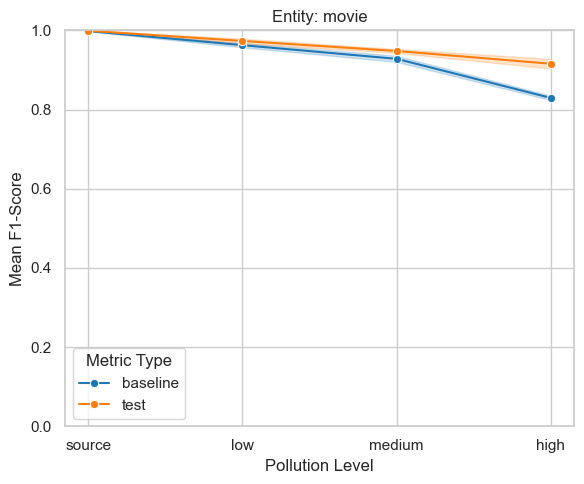

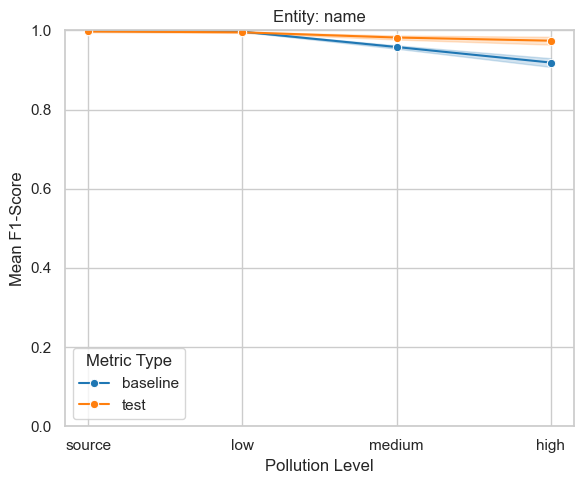

In [209]:
df = query_metrics(9790002)

latex_code = df.to_latex(
    index=False, 
    caption="Summary of F1 Scores across Multiple Runs",
    label="tab:f1_results",
    float_format="%.4f"
)

print(latex_code)

plot_degradation(df, "imdb", "main", "roberta")

## IMDB Prelim

\begin{table}
\caption{Summary of F1 Scores across Multiple Runs}
\label{tab:f1_results}
\begin{tabular}{lllrrrrlr}
\toprule
dataset & entity & metric_type & mean_f1 & std_f1 & num_seeds & train_size & pollution & epochs \\
\midrule
imdb & movie & baseline & 0.9984 & 0.0009 & 5 & 1.0000 & source & 10 \\
imdb & movie & phase1 & 0.9990 & 0.0007 & 5 & 1.0000 & source & 10 \\
imdb & movie & phase2 & 0.9988 & 0.0016 & 5 & 1.0000 & source & 10 \\
imdb & movie & baseline & 0.9627 & 0.0055 & 4 & 1.0000 & low & 10 \\
imdb & movie & phase1 & 0.9702 & 0.0043 & 5 & 1.0000 & low & 10 \\
imdb & movie & phase2 & 0.9730 & 0.0039 & 5 & 1.0000 & low & 10 \\
imdb & movie & baseline & 0.9282 & 0.0078 & 5 & 1.0000 & medium & 10 \\
imdb & movie & phase1 & 0.9243 & 0.0060 & 4 & 1.0000 & medium & 10 \\
imdb & movie & phase2 & 0.9475 & 0.0047 & 4 & 1.0000 & medium & 10 \\
imdb & movie & baseline & 0.8294 & 0.0056 & 5 & 1.0000 & high & 10 \\
imdb & movie & phase1 & 0.8352 & 0.0052 & 5 & 1.0000 & high & 10 \\
im

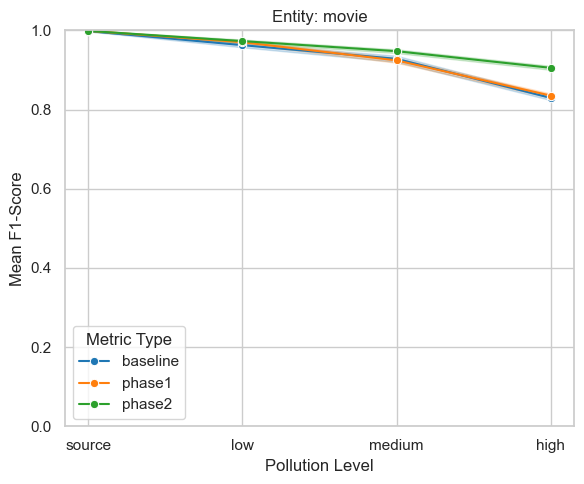

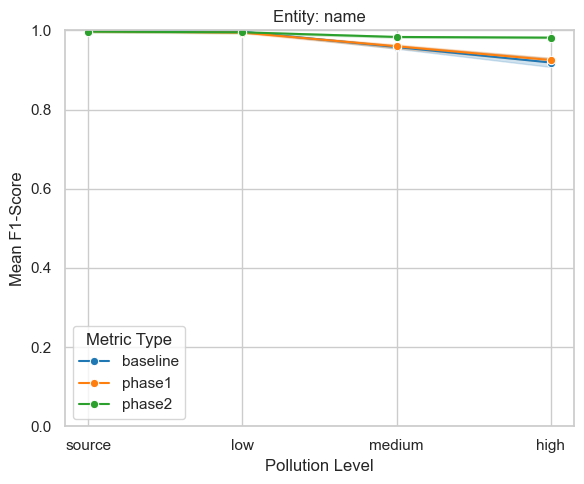

In [210]:
df = query_prelimary(9790002)

latex_code = df.to_latex(
    index=False, 
    caption="Summary of F1 Scores across Multiple Runs",
    label="tab:f1_results",
    float_format="%.4f"
)

print(latex_code)

plot_degradation(df, "imdb", "prelim")

# JOB ID: 9790092

Dataset: music

Trainset size: Full

Pollutions: source, low, medium, high

lm: roberta

## Main

\begin{table}[h]
\centering
\caption{Comparison of F1 Scores: Baseline vs. Test (test) - Dataset music}
\label{tab:f1_comparison_auto}
\begin{tabular}{ll c cc c cc}
\toprule
 & & & \multicolumn{2}{c}{\textbf{Baseline}} & & \multicolumn{2}{c}{\textbf{Test (Test)}} \\
\cmidrule{4-5} \cmidrule{7-8}
\textbf{Entity} & \textbf{Pollution} & & \textbf{Mean F1} & \textbf{SD} & & \textbf{Mean F1} & \textbf{SD} \\
\midrule
area & source & & \textbf{0.9622} & 0.0174 & & 0.8640 & 0.2596 \\
area & low & & 0.9266 & 0.0022 & & \textbf{0.9592} & 0.0145 \\
area & medium & & 0.8918 & 0.0318 & & 0.8918 & 0.0184 \\
area & high & & 0.4386 & 0.0098 & & \textbf{0.5886} & 0.1701 \\
artist & source & & \textbf{0.9992} & 0.0018 & & 0.9962 & 0.0039 \\
artist & low & & \textbf{1.0000} & 0.0000 & & 0.9926 & 0.0046 \\
artist & medium & & \textbf{0.9976} & 0.0033 & & 0.9946 & 0.0049 \\
artist & high & & \textbf{0.9980} & nan & & 0.9838 & 0.0083 \\
artist_credit & source & & 0.9874 & 0.0031 & & \textbf{0.9950} & 0.003

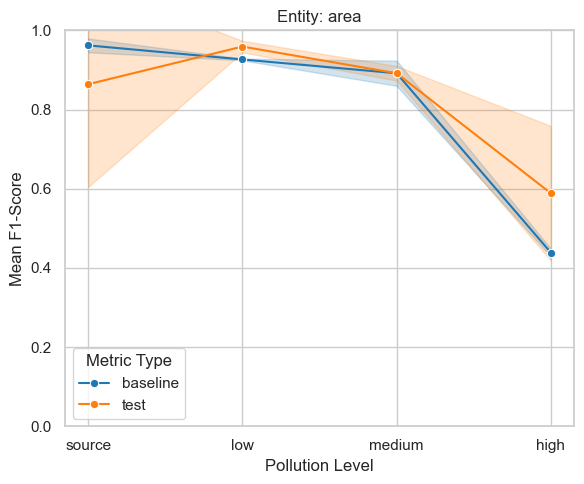

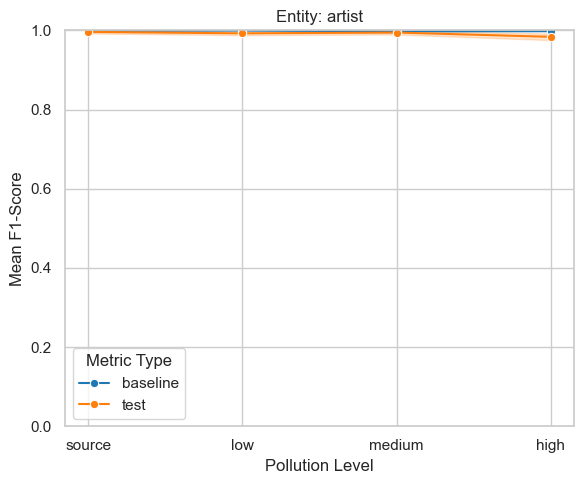

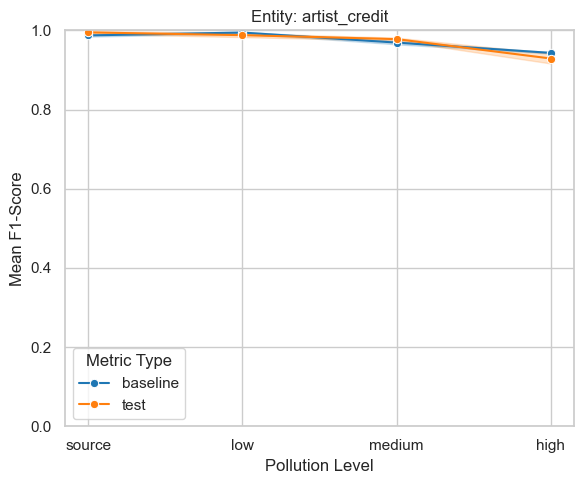

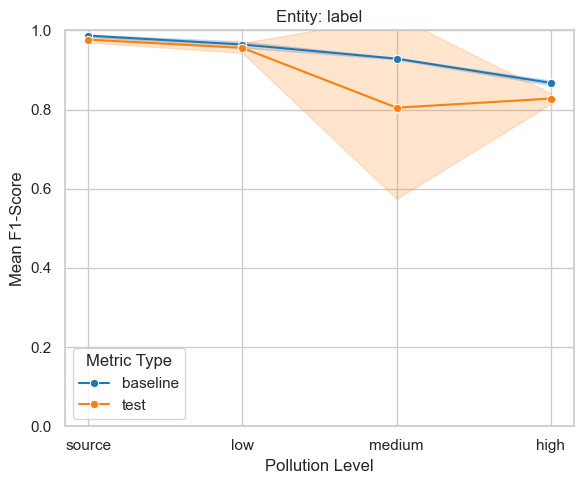

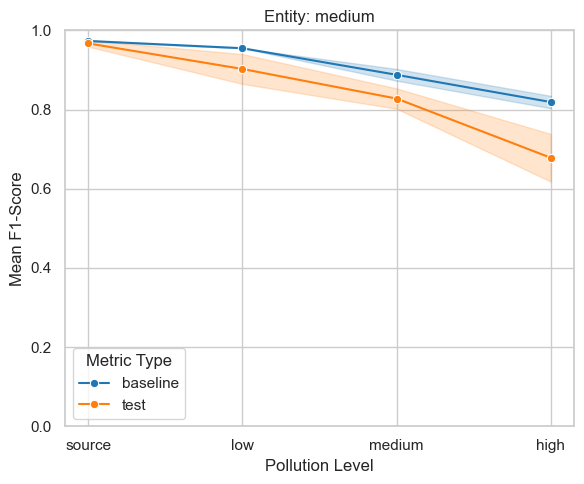

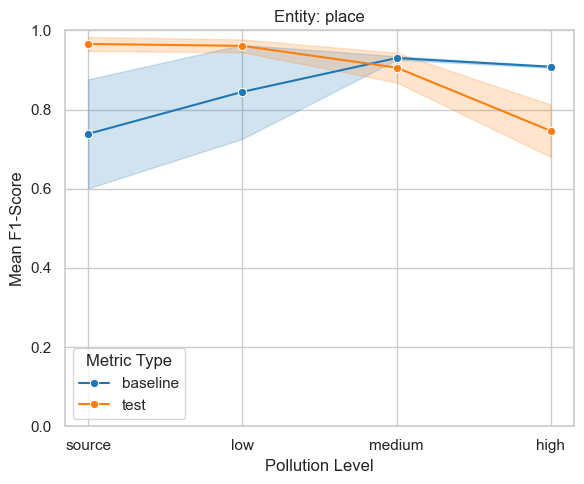

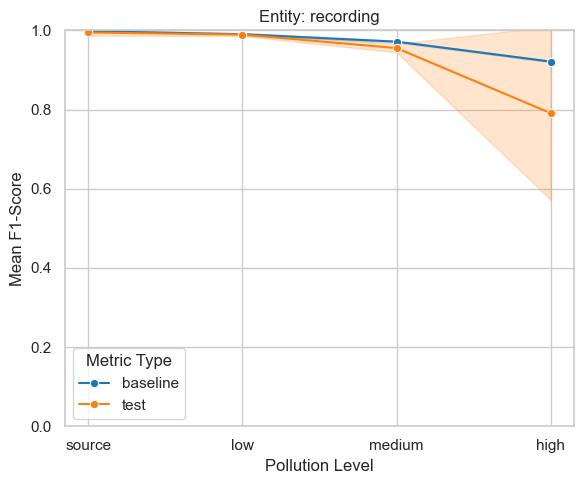

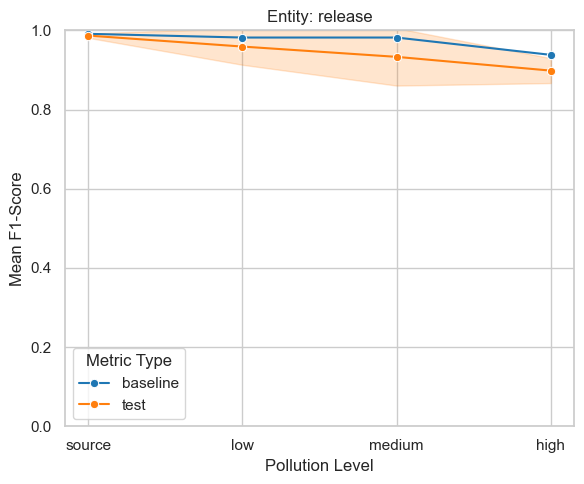

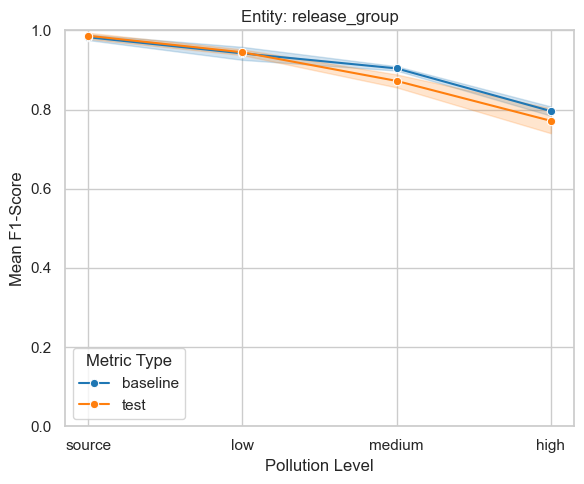

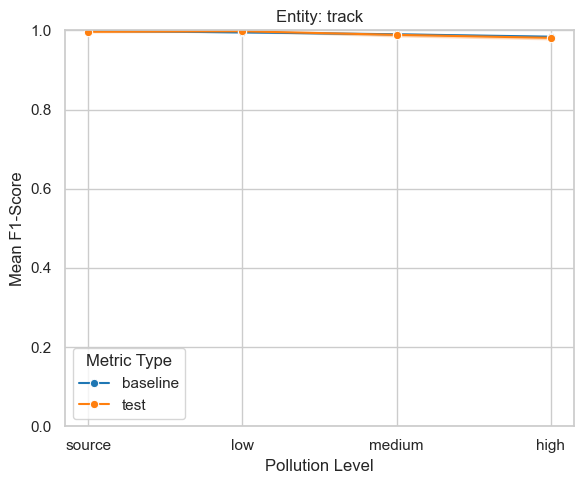

In [211]:
df = query_metrics(9790092)

# latex_code = df.to_latex(
#     index=False, 
#     caption="Summary of F1 Scores across Multiple Runs",
#     label="tab:f1_results",
#     float_format="%.4f"
# )

# 1. Define the logical order
pollution_order = ['source', 'low', 'medium', 'high']

# 2. Apply the categorical type to the column
df['pollution'] = pd.Categorical(
    df['pollution'], 
    categories=pollution_order, 
    ordered=True
)

# 3. Sort the DataFrame to reflect this order
# This ensures that when you generate the table or plot, the rows are in order
df = df.sort_values(by=['dataset', 'entity', 'pollution', 'metric_type'])

latex_code = generate_comparison_latex(df, test_metric='test')

print(latex_code)

plot_degradation(df, "music", "main")

### Investigate high SD

In [212]:
# Define your threshold
threshold = 0.05

# Filter the aggregated dataframe to find problematic configurations
high_sd_df = df[df['std_f1'] > threshold].copy()

print(f"Found {len(high_sd_df)} rows with Standard Deviation > {threshold}")
display(high_sd_df)

Found 9 rows with Standard Deviation > 0.05


,dataset,entity,metric_type,mean_f1,std_f1,num_seeds,train_size,pollution,epochs
7,music,area,test,0.8640,0.259577,5,1.0,source,10
4,music,area,test,0.5886,0.170110,5,1.0,high,10
30,music,label,test,0.8048,0.230303,5,1.0,medium,10
36,music,medium,test,0.6782,0.060218,5,1.0,high,10
43,music,place,baseline,0.7386,0.137742,5,1.0,source,10
41,music,place,baseline,0.8448,0.118856,5,1.0,low,10
44,music,place,test,0.7462,0.066285,5,1.0,high,10
52,music,recording,test,0.7908,0.219271,5,1.0,high,10
62,music,release,test,0.9332,0.072565,5,1.0,medium,10


In [213]:
# Get all run_ids for high sd rows
def investigate_outliers(outlier_row, job_id):
    """
    Fetches raw scores for all seeds associated with a high-SD configuration.
    """
    # Extract row identifiers
    dataset = outlier_row['dataset']
    entity = outlier_row['entity']
    m_type = outlier_row['metric_type']
    pollution = outlier_row['pollution']

    # Query individual runs
    query = f"""
    SELECT 
        m.run_id,
        m.entity,
        r.seed,
        m.f1_score,
        m.precision,
        m.recall,
        m.iteration
    FROM runs r
    JOIN metrics m ON r.run_id = m.run_id
    WHERE r.dataset = '{dataset}'
      AND m.entity = '{entity}'
      AND m.metric_type = '{m_type}'
      AND r.pollution = '{pollution}'
      AND m.run_id LIKE '{job_id}_%'

    ORDER BY m.f1_score ASC;
    """
    
    raw_metrics_df = run_sql_query(query)
    return raw_metrics_df

# Example: Investigate the first row in your high_sd_df
outlier_details = investigate_outliers(high_sd_df.iloc[1], 9790092)
display(outlier_details)

,run_id,entity,seed,f1_score,precision,recall,iteration
0,9790092_15,area,1,0.400,0.250,1.000,0
1,9790092_15,area,1,0.400,0.250,1.000,1
2,9790092_18,area,4,0.405,0.533,0.327,0
3,9790092_18,area,4,0.405,0.533,0.327,1
4,9790092_19,area,5,0.699,0.853,0.592,0
5,9790092_19,area,5,0.699,0.853,0.592,1
6,9790092_17,area,3,0.717,0.767,0.673,0
7,9790092_17,area,3,0.717,0.767,0.673,1
8,9790092_16,area,2,0.722,0.661,0.796,0
9,9790092_16,area,2,0.722,0.661,0.796,1


## Prelim

\begin{table}[h]
\centering
\caption{Comparison of F1 Scores: Baseline vs. Phase 1 vs. Phase 2 - Dataset music}
\label{tab:f1_comparison_phases}
\begin{tabular}{ll c cc c cc c cc}
\toprule
 & & & \multicolumn{2}{c}{\textbf{Baseline}} & & \multicolumn{2}{c}{\textbf{Phase 1}} & & \multicolumn{2}{c}{\textbf{Phase 2}} \\
\cmidrule{4-5} \cmidrule{7-8} \cmidrule{10-11}
\textbf{Entity} & \textbf{Pollution} & & \textbf{Mean} & \textbf{SD} & & \textbf{Mean} & \textbf{SD} & & \textbf{Mean} & \textbf{SD} \\
\midrule
area & source & & \textbf{0.9622} & 0.0174 & & 0.8396 & 0.2474 & & 0.8558 & 0.2551 \\
area & low & & 0.9266 & 0.0022 & & 0.8272 & 0.2409 & & \textbf{0.9530} & 0.0117 \\
area & medium & & \textbf{0.8918} & 0.0318 & & 0.8656 & 0.0252 & & 0.8910 & 0.0143 \\
area & high & & 0.4386 & 0.0098 & & 0.4336 & 0.0740 & & \textbf{0.6358} & 0.1885 \\
artist & source & & 0.9992 & 0.0018 & & 0.9976 & 0.0022 & & \textbf{1.0000} & 0.0000 \\
artist & low & & \textbf{1.0000} & 0.0000 & & 0.9992 & 0.0018 

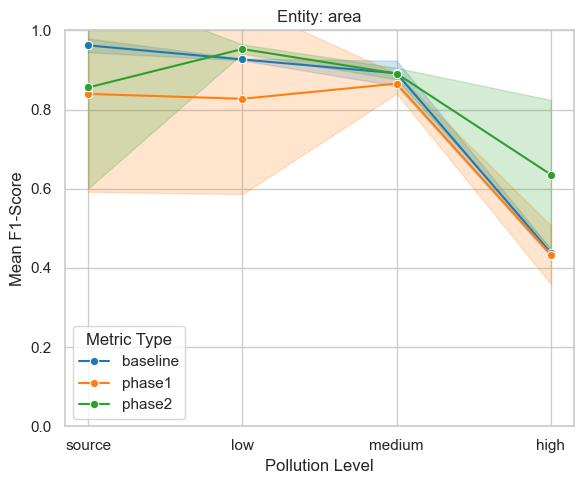

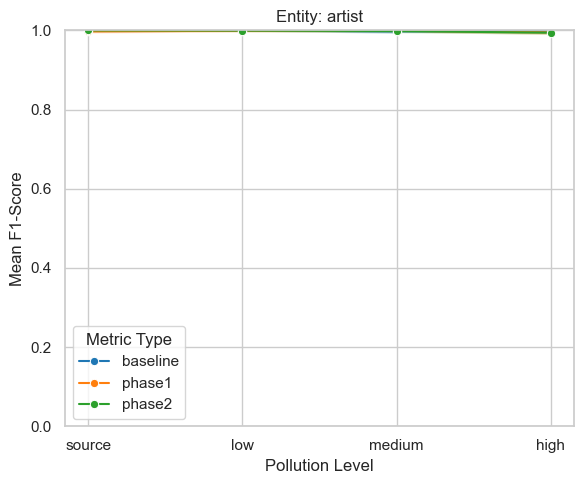

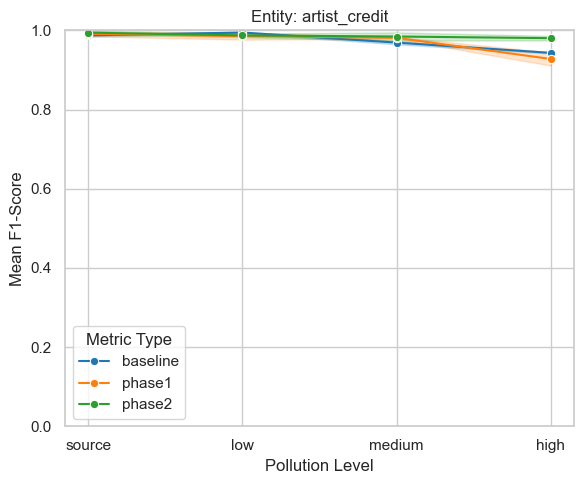

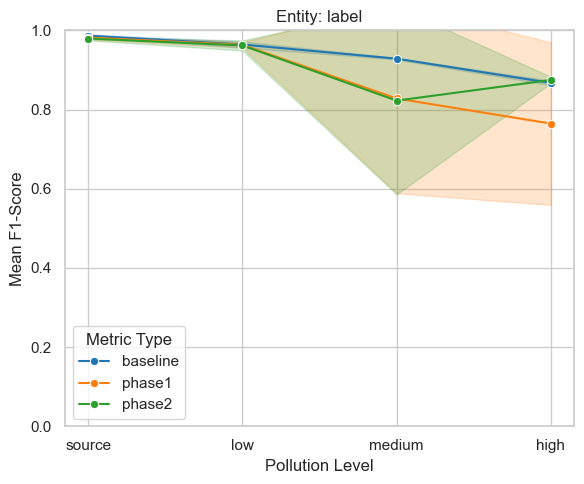

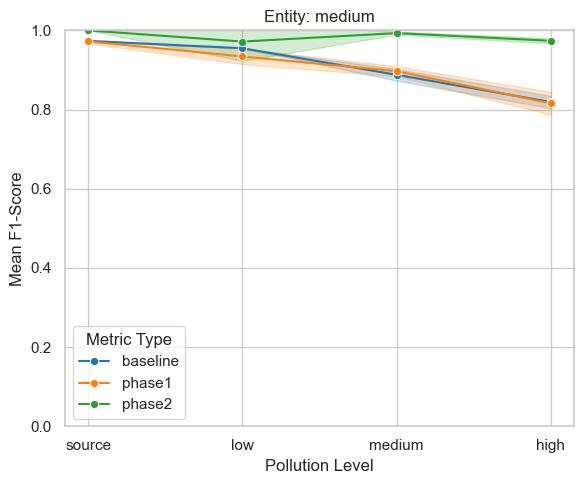

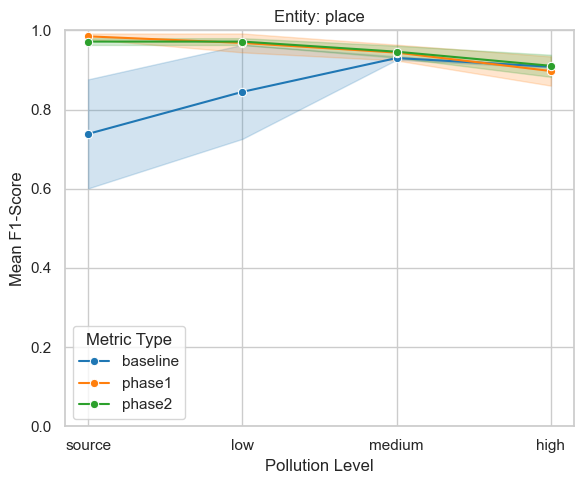

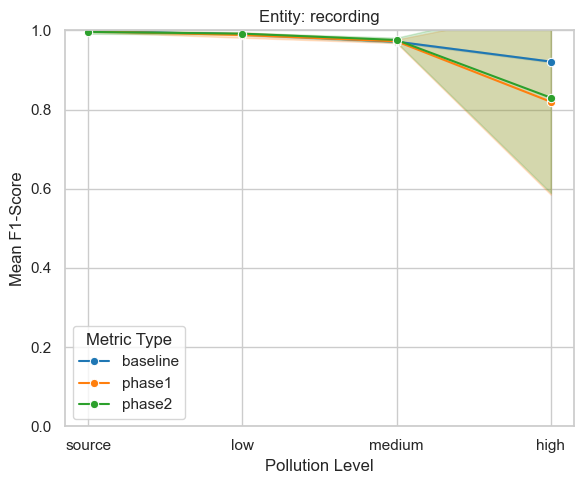

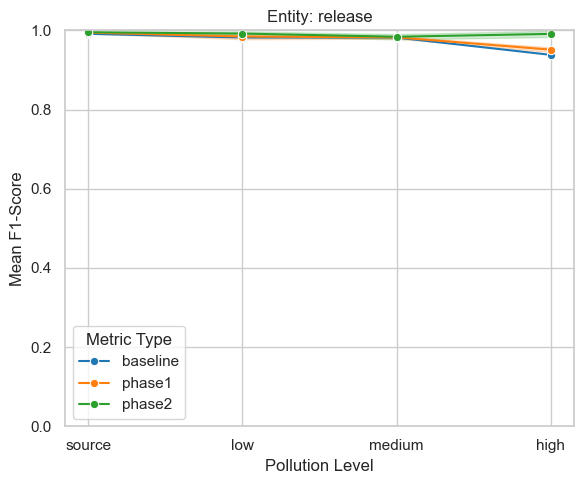

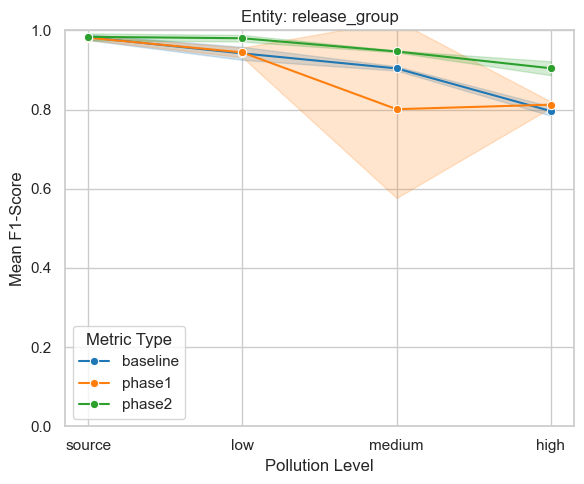

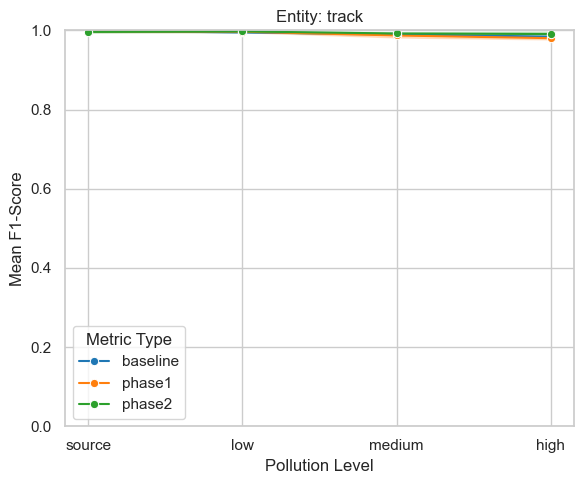

In [214]:
# Signal validity

df = query_prelimary(9790092)

latex_code = df.to_latex(
    index=False, 
    caption="Summary of F1 Scores across Multiple Runs",
    label="tab:f1_results",
    float_format="%.4f"
)

latex_code = generate_comparison_latex_prelim(df, "music")

print(latex_code)

plot_degradation(df, "music", "prelim")

# JOB ID: 9790670

Dataset: IMDB

Trainset size: Full

Pollutions: source, low, medium, high

lm: distillbert

Error: Metric types 'baseline' or 'test' not found in DataFrame.


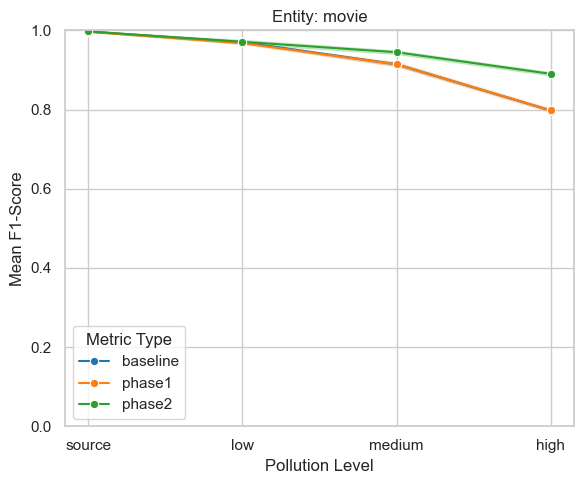

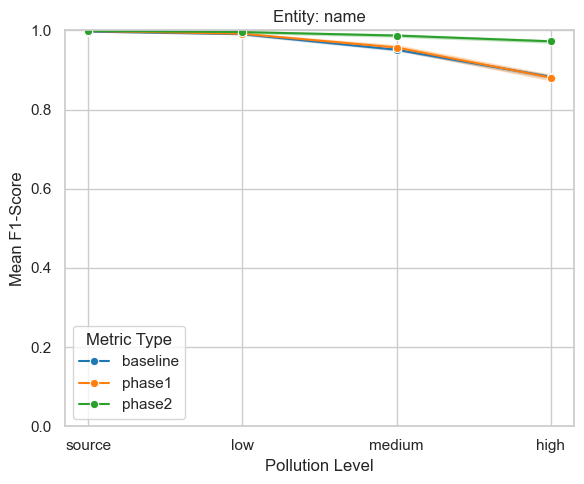

In [217]:
imdb_distillbert = 9790670
df = query_prelimary(imdb_distillbert)

# 1. Define the logical order
pollution_order = ['source', 'low', 'medium', 'high']

# 2. Apply the categorical type to the column
df['pollution'] = pd.Categorical(
    df['pollution'], 
    categories=pollution_order, 
    ordered=True
)

# 3. Sort the DataFrame to reflect this order
# This ensures that when you generate the table or plot, the rows are in order
df = df.sort_values(by=['dataset', 'entity', 'pollution', 'metric_type'])

latex_code = generate_comparison_latex(df, test_metric='test')

print(latex_code)

plot_degradation(df, "imdb", "prelim", "distillbert")

\begin{table}[h]
\centering
\caption{Comparison of F1 Scores: Baseline vs. Test (test) - Dataset music}
\label{tab:f1_comparison_auto}
\begin{tabular}{ll c cc c cc}
\toprule
 & & & \multicolumn{2}{c}{\textbf{Baseline}} & & \multicolumn{2}{c}{\textbf{Test (Test)}} \\
\cmidrule{4-5} \cmidrule{7-8}
\textbf{Entity} & \textbf{Pollution} & & \textbf{Mean F1} & \textbf{SD} & & \textbf{Mean F1} & \textbf{SD} \\
\midrule
movie & source & & 0.9972 & 0.0004 & & \textbf{0.9974} & 0.0005 \\
movie & low & & 0.9704 & 0.0015 & & \textbf{0.9716} & 0.0052 \\
movie & medium & & 0.9144 & 0.0033 & & \textbf{0.9434} & 0.0111 \\
movie & high & & 0.7976 & 0.0009 & & \textbf{0.9014} & 0.0090 \\
name & source & & 0.9970 & nan & & \textbf{0.9988} & 0.0011 \\
name & low & & 0.9904 & 0.0019 & & \textbf{0.9954} & 0.0029 \\
name & medium & & 0.9512 & 0.0020 & & \textbf{0.9688} & 0.0108 \\
name & high & & 0.8826 & 0.0043 & & \textbf{0.9292} & 0.0157 \\
\bottomrule
\end{tabular}
\end{table}


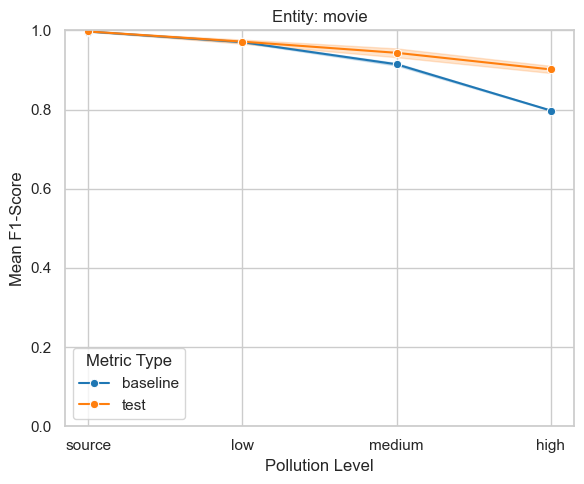

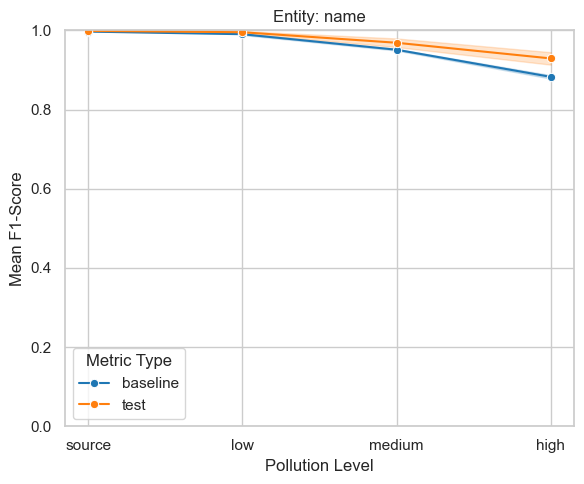

In [218]:
df = query_metrics(imdb_distillbert)

# 1. Define the logical order
pollution_order = ['source', 'low', 'medium', 'high']

# 2. Apply the categorical type to the column
df['pollution'] = pd.Categorical(
    df['pollution'], 
    categories=pollution_order, 
    ordered=True
)

# 3. Sort the DataFrame to reflect this order
# This ensures that when you generate the table or plot, the rows are in order
df = df.sort_values(by=['dataset', 'entity', 'pollution', 'metric_type'])

latex_code = generate_comparison_latex(df, test_metric='test')

print(latex_code)

plot_degradation(df, "imdb", "main", "distillbert")

# JOB ID: 9790709

Dataset: music

Trainset size: Full

Pollutions: source, low, medium, high

lm: distillbert

\begin{table}[h]
\centering
\caption{Comparison of F1 Scores: Baseline vs. Phase 1 vs. Phase 2 - Dataset music}
\label{tab:f1_comparison_phases}
\begin{tabular}{ll c cc c cc c cc}
\toprule
 & & & \multicolumn{2}{c}{\textbf{Baseline}} & & \multicolumn{2}{c}{\textbf{Phase 1}} & & \multicolumn{2}{c}{\textbf{Phase 2}} \\
\cmidrule{4-5} \cmidrule{7-8} \cmidrule{10-11}
\textbf{Entity} & \textbf{Pollution} & & \textbf{Mean} & \textbf{SD} & & \textbf{Mean} & \textbf{SD} & & \textbf{Mean} & \textbf{SD} \\
\midrule
area & source & & \textbf{0.8436} & 0.0434 & & 0.7850 & 0.0342 & & 0.8348 & 0.0194 \\
area & low & & 0.7488 & 0.0427 & & 0.7034 & 0.0477 & & \textbf{0.7756} & 0.0342 \\
area & medium & & 0.6144 & 0.0252 & & 0.5602 & 0.0344 & & \textbf{0.7350} & 0.0492 \\
area & high & & 0.4384 & 0.0322 & & 0.4308 & 0.0623 & & \textbf{0.5952} & 0.0552 \\
artist & source & & 0.9922 & 0.0040 & & \textbf{0.9968} & 0.0041 & & 0.9964 & 0.0043 \\
artist & low & & 0.9956 & 0.0022 & & 0.9964 & 0.0030 & & \text

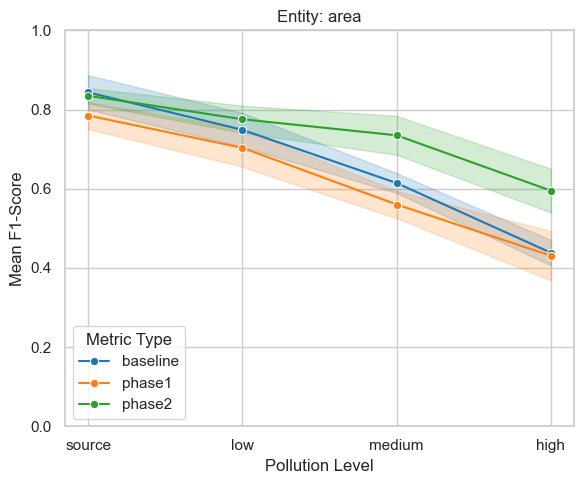

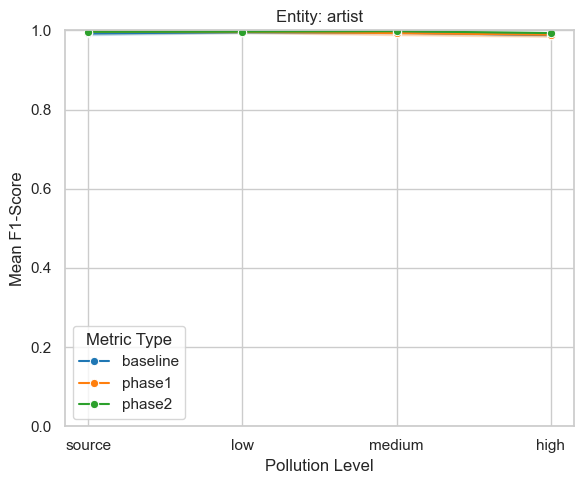

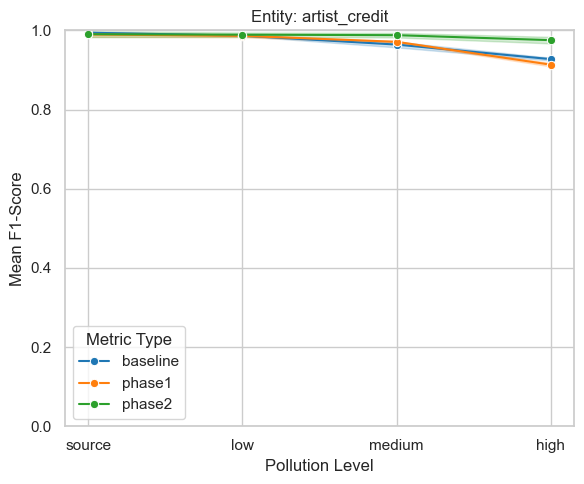

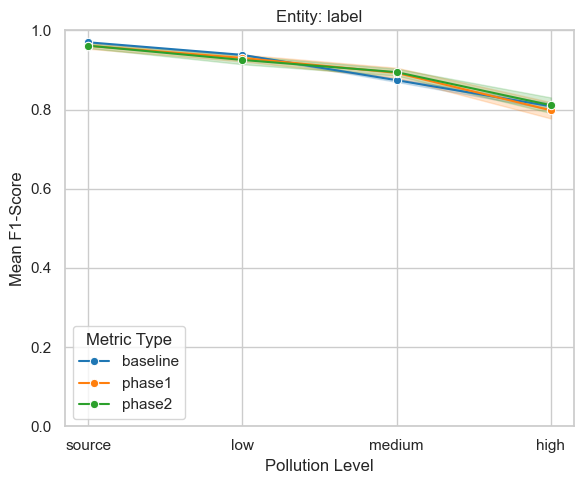

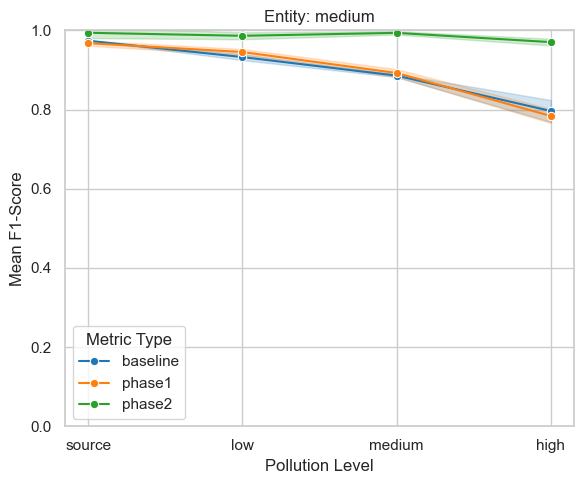

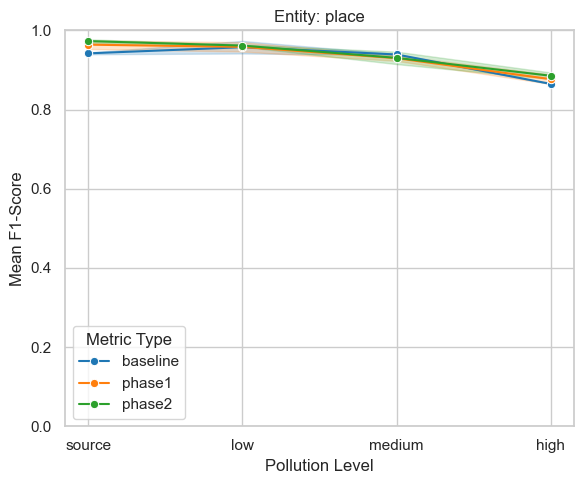

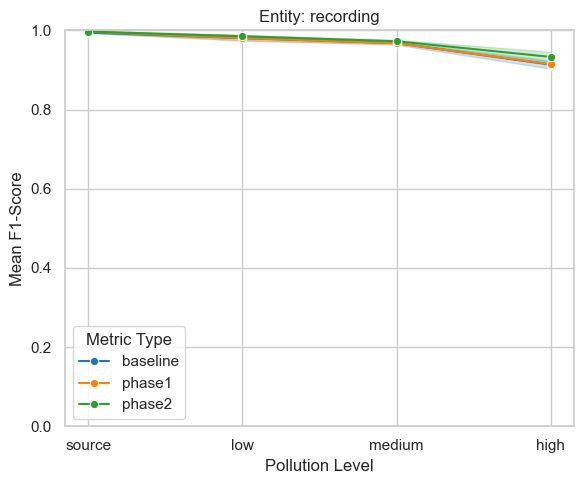

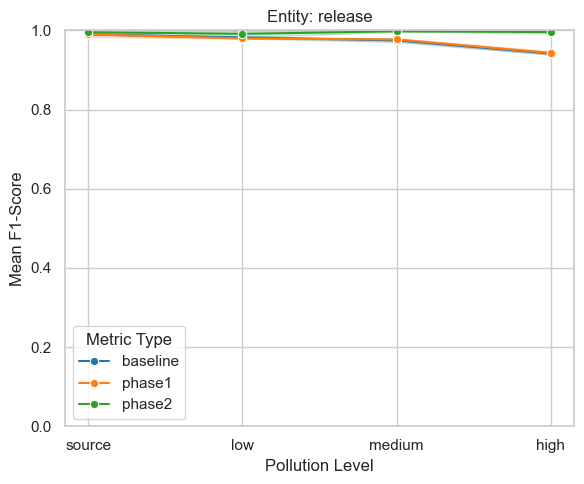

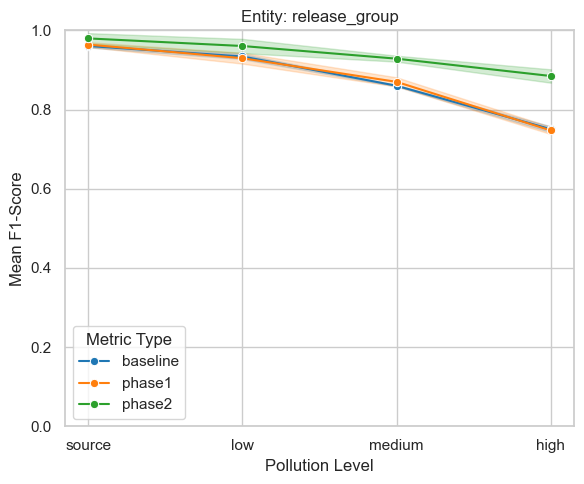

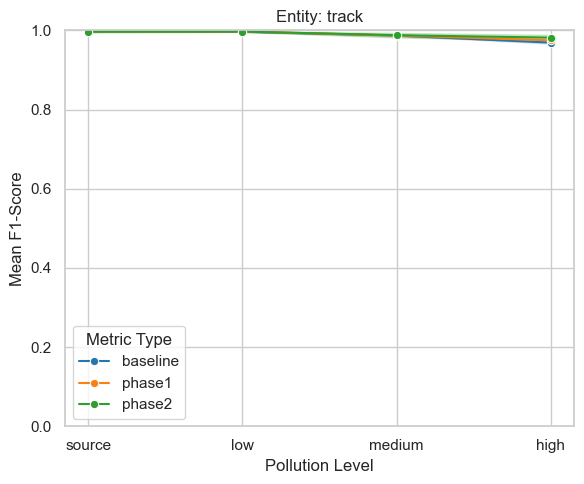

In [222]:
music_distillbert = 9790709
df = query_prelimary(music_distillbert)

# 1. Define the logical order
pollution_order = ['source', 'low', 'medium', 'high']

# 2. Apply the categorical type to the column
df['pollution'] = pd.Categorical(
    df['pollution'], 
    categories=pollution_order, 
    ordered=True
)

# 3. Sort the DataFrame to reflect this order
# This ensures that when you generate the table or plot, the rows are in order
df = df.sort_values(by=['dataset', 'entity', 'pollution', 'metric_type'])

latex_code = generate_comparison_latex_prelim(df)

print(latex_code)

plot_degradation(df, "imdb", "prelim", "distillbert")

\begin{table}[h]
\centering
\caption{Comparison of F1 Scores: Baseline vs. Test (test) - Dataset music}
\label{tab:f1_comparison_auto}
\begin{tabular}{ll c cc c cc}
\toprule
 & & & \multicolumn{2}{c}{\textbf{Baseline}} & & \multicolumn{2}{c}{\textbf{Test (Test)}} \\
\cmidrule{4-5} \cmidrule{7-8}
\textbf{Entity} & \textbf{Pollution} & & \textbf{Mean F1} & \textbf{SD} & & \textbf{Mean F1} & \textbf{SD} \\
\midrule
area & source & & \textbf{0.8436} & 0.0434 & & 0.8176 & 0.0142 \\
area & low & & \textbf{0.7488} & 0.0427 & & 0.7432 & 0.0248 \\
area & medium & & 0.6144 & 0.0252 & & \textbf{0.6974} & 0.0316 \\
area & high & & 0.4384 & 0.0322 & & \textbf{0.4984} & 0.0250 \\
artist & source & & \textbf{0.9922} & 0.0040 & & 0.9384 & 0.0328 \\
artist & low & & \textbf{0.9956} & 0.0022 & & 0.9242 & 0.0512 \\
artist & medium & & \textbf{0.9944} & 0.0022 & & 0.9292 & 0.0345 \\
artist & high & & \textbf{0.9882} & 0.0018 & & 0.8234 & 0.1132 \\
artist_credit & source & & \textbf{0.9942} & 0.0018 & & 0.

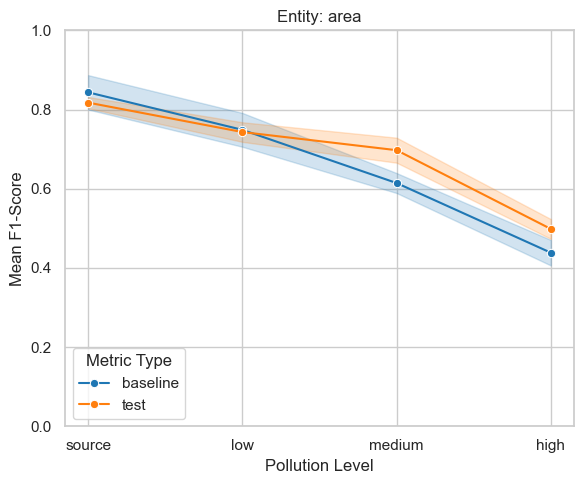

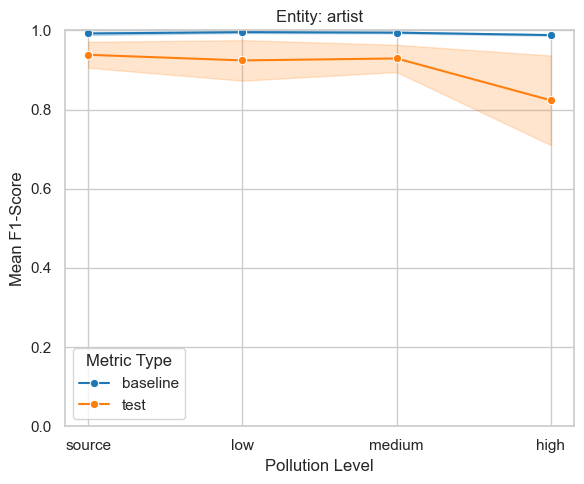

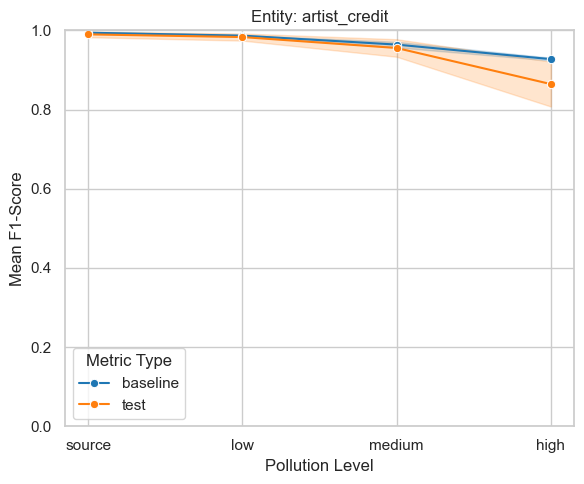

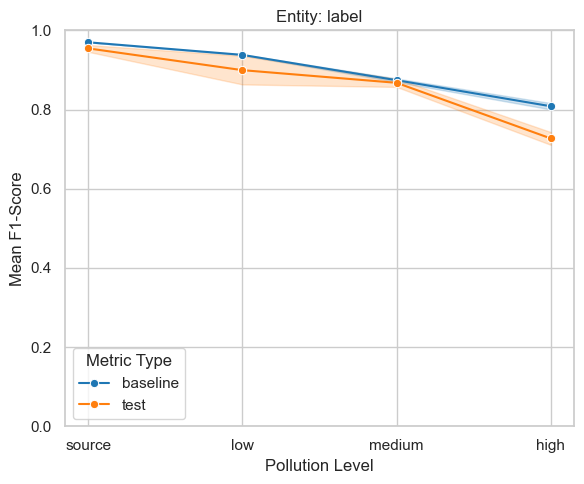

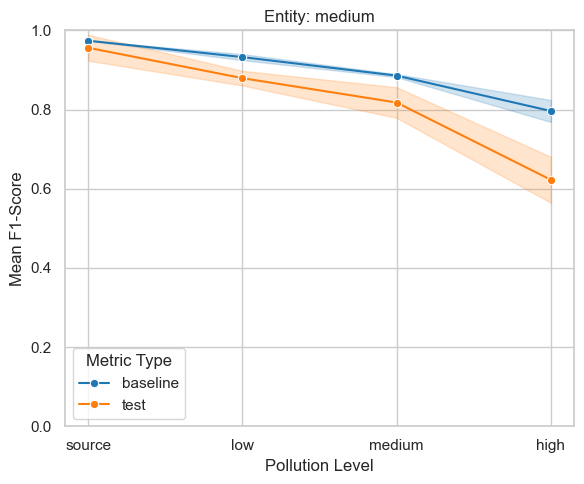

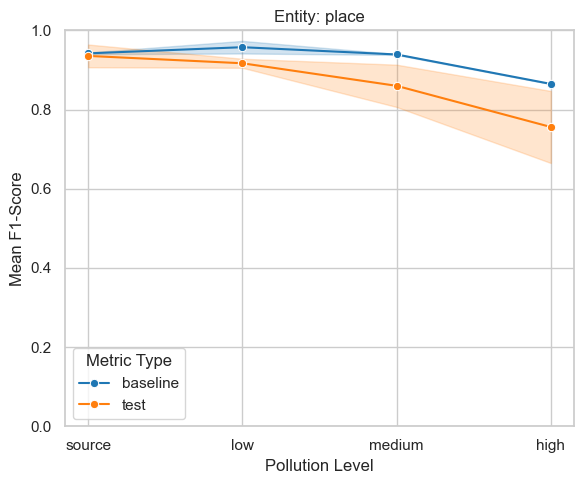

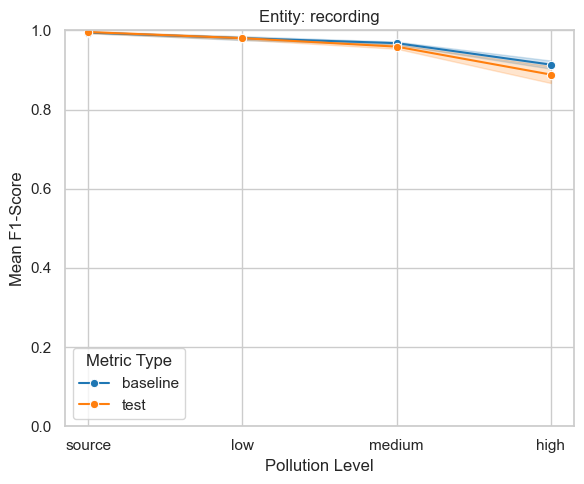

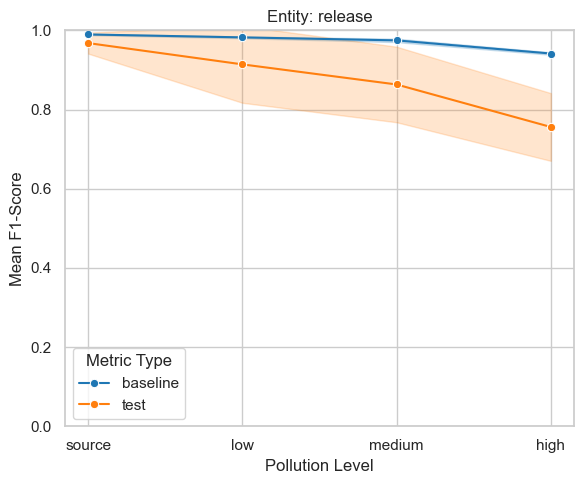

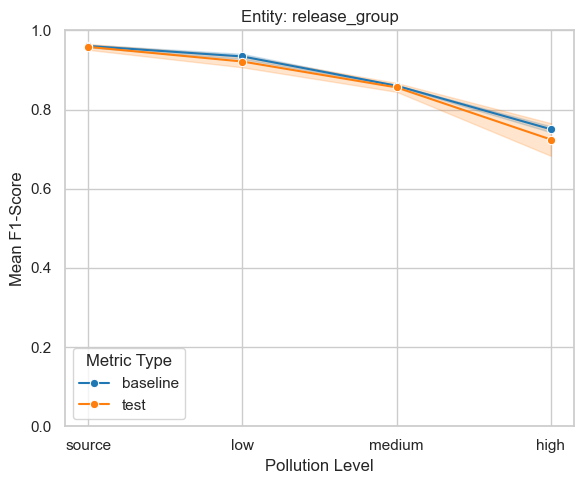

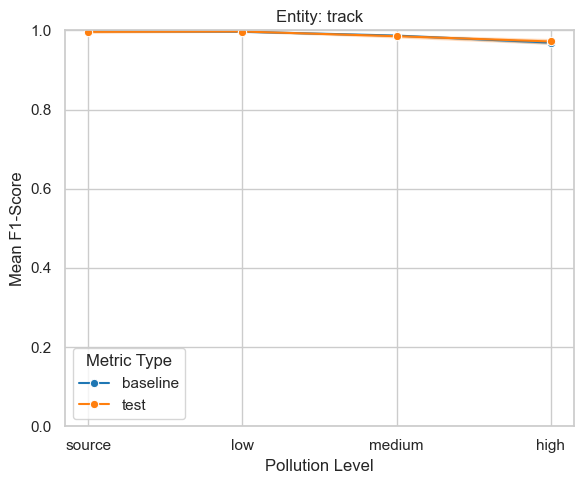

In [220]:
df = query_metrics(music_distillbert)

# 1. Define the logical order
pollution_order = ['source', 'low', 'medium', 'high']

# 2. Apply the categorical type to the column
df['pollution'] = pd.Categorical(
    df['pollution'], 
    categories=pollution_order, 
    ordered=True
)

# 3. Sort the DataFrame to reflect this order
# This ensures that when you generate the table or plot, the rows are in order
df = df.sort_values(by=['dataset', 'entity', 'pollution', 'metric_type'])

latex_code = generate_comparison_latex(df, test_metric='test')

print(latex_code)

plot_degradation(df, "imdb", "main", "distillbert")

# 9790854

- Changed Learning rate for refinetune to 1e-5
- changed relational scores to "" for iteration 0 
- changed relational scores to "" if neighborhood is empty
- increased max sequence length to 512